# WEEK 6:

# **Feature Engineering: Normalization, Scaling, Encoding & Skewness Fixing:**


Feature engineering improves the quality of the dataset by transforming variables into a form that machine learning algorithms can understand better. In this stage we will:

Normalize numerical variables
Standardize data using scaling
Encode categorical variables
Detect and correct skewed distributions

# **Import Libraries:**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew

We import the necessary libraries required for feature engineering.

pandas → Used for data manipulation and analysis

numpy → Used for numerical operations

matplotlib & seaborn → Used for visualization

sklearn preprocessing → Used for normalization, scaling, and encoding

scipy.stats → Used to measure skewness of the data

# **Load Dataset**

In [12]:
df = pd.read_csv("/content/retail_store_sales.csv")
print(df.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          


The dataset is loaded into a dataframe called df.
The head() function displays the first few rows so we can verify that the dataset is loaded correctly.

# **Convert Columns to Numeric**

In [13]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

Some datasets contain numeric values stored as text.
pd.to_numeric() converts them into numeric format so that calculations can be performed.

errors='coerce' replaces invalid values with NaN.

# **Handle Missing Values**

In [14]:
df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Total Spent'].fillna(df['Total Spent'].mean(), inplace=True)

df['Item'].fillna(df['Item'].mode()[0], inplace=True)
df['Discount Applied'].fillna("False", inplace=True)

/tmp/ipykernel_2835/2839730694.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)
/tmp/ipykernel_2835/2839730694.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Missing values can affect analysis and machine learning models.

We handle them using:

Mean for Price Per Unit
Median for Quantity (more robust to outliers)
Mode for categorical variables like Item

This ensures that the dataset becomes complet

# **Visualizing Distribution Before Scaling**

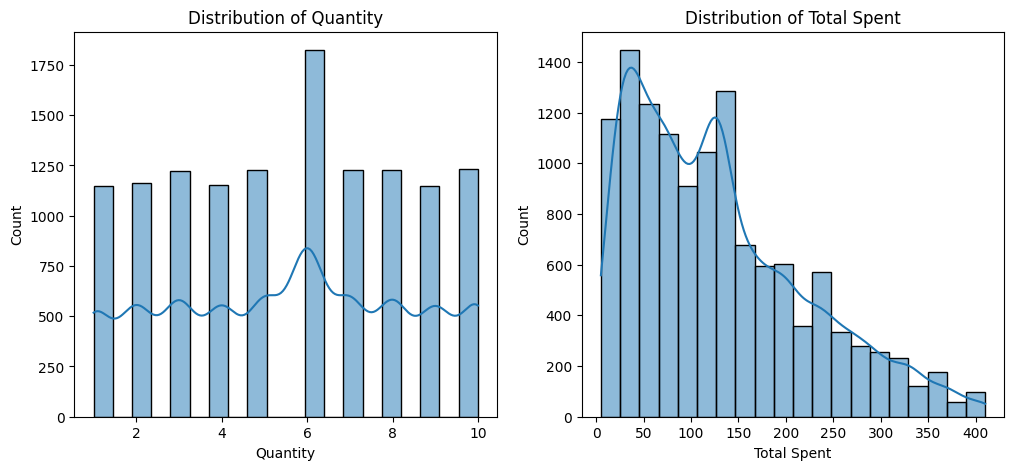

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Quantity'], bins=20, kde=True)
plt.title("Distribution of Quantity")
plt.subplot(1,2,2)
sns.histplot(df['Total Spent'], bins=20, kde=True)
plt.title("Distribution of Total Spent")
plt.show()

Histograms help us understand how data is distributed.

Insights

Quantity

Shows how often each quantity value appears in transactions.

Total Spent

Shows spending patterns of customers.

The KDE curve shows the smooth distribution of the data.

This helps identify whether the data is normal, skewed, or unevenly distributed.

# **Detect Skewness**

In [16]:
print("Skewness of Quantity:", skew(df['Quantity']))
print("Skewness of Total Spent:", skew(df['Total Spent']))

Skewness of Quantity: -0.035945058567359744
Skewness of Total Spent: 0.8519015598266656


# **Fix Skewness using Log Transformation**

In [17]:
df['Total Spent Log'] = np.log1p(df['Total Spent'])

log1p() applies a logarithmic transformation to reduce skewness.

This helps compress large values and makes the data distribution more balanced.

# **Visualization After Skewness Fix**

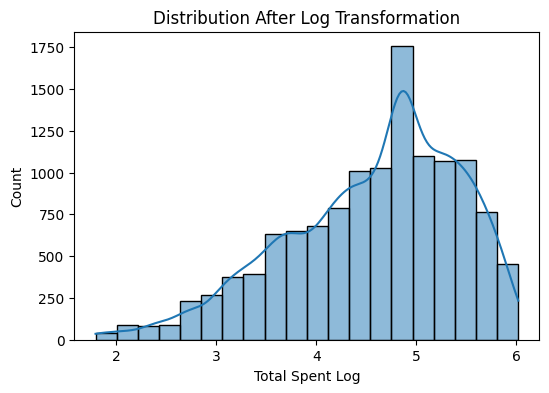

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['Total Spent Log'], bins=20, kde=True)
plt.title("Distribution After Log Transformation")
plt.show()

After transformation, the distribution becomes more balanced.

This improves the performance of machine learning models.

# **Normalization (Min-Max Scaling)**

In [19]:
scaler = MinMaxScaler()

df[['Quantity_norm','Total_norm']] = scaler.fit_transform(
    df[['Quantity','Total Spent']]
)

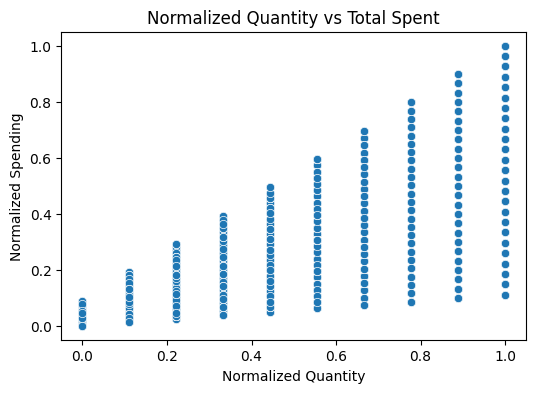

In [20]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=df['Quantity_norm'], y=df['Total_norm'])

plt.title("Normalized Quantity vs Total Spent")
plt.xlabel("Normalized Quantity")
plt.ylabel("Normalized Spending")

plt.show()

Normalization scales values between 0 and 1.

This prevents variables with larger values from dominating the model.

The scatter plot shows the relationship between normalized variables.

# **Standard Scaling**

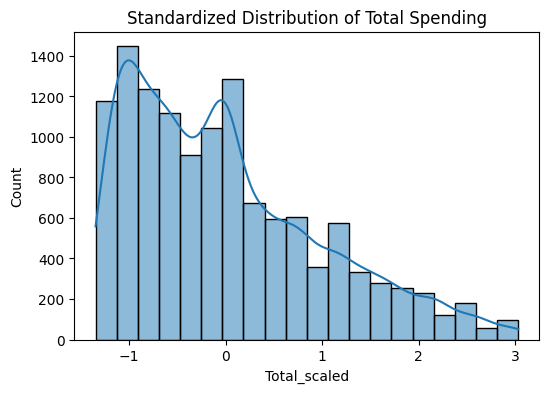

In [22]:
scaler = StandardScaler()

df[['Price_scaled','Quantity_scaled','Total_scaled']] = scaler.fit_transform(
    df[['Price Per Unit','Quantity','Total Spent']]
)
plt.figure(figsize=(6,4))

sns.histplot(df['Total_scaled'], bins=20, kde=True)

plt.title("Standardized Distribution of Total Spending")
plt.show()

Standardization transforms data so that:

Mean = 0

Standard deviation = 1

This is important for algorithms such as:

SVM
Logistic Regression
PCA

# **Encoding Categorical Variables**

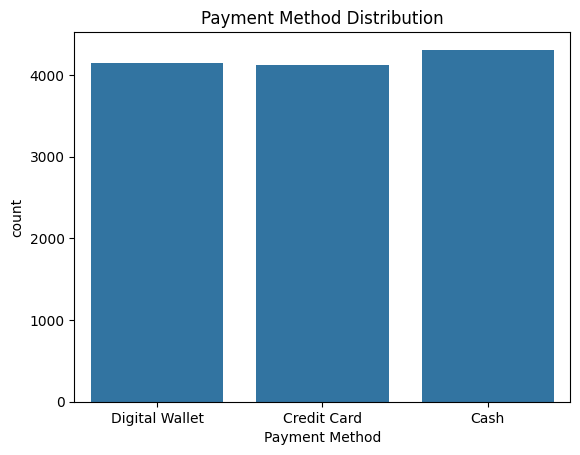

In [23]:
le = LabelEncoder()
df['Payment Method Encoded'] = le.fit_transform(df['Payment Method'])
sns.countplot(x=df['Payment Method'])
plt.title("Payment Method Distribution")
plt.show()

Label encoding converts categorical values into numeric values.

Example mapping:

Cash → 0
Card → 1
Digital Wallet → 2

This allows machine learning models to process categorical variables.

# **One-Hot Encoding**

In [25]:
df_encoded = pd.get_dummies(df, columns=['Payment Method'])

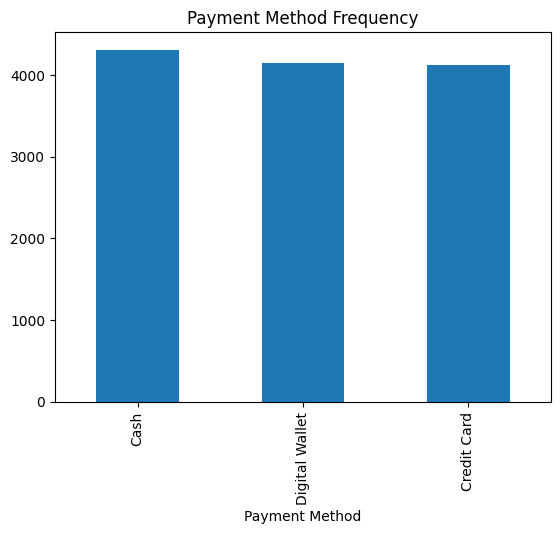

In [26]:
df['Payment Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Frequency")
plt.show()

One-hot encoding creates a separate column for each category.

Example:

Location_Online
Location_In-store

Each column contains 1 if the category is present and 0 otherwise.

This prevents the model from assuming ordinal relationships.

# **Label Encoding**

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Payment Method_encoded'] = le.fit_transform(df['Payment Method'])

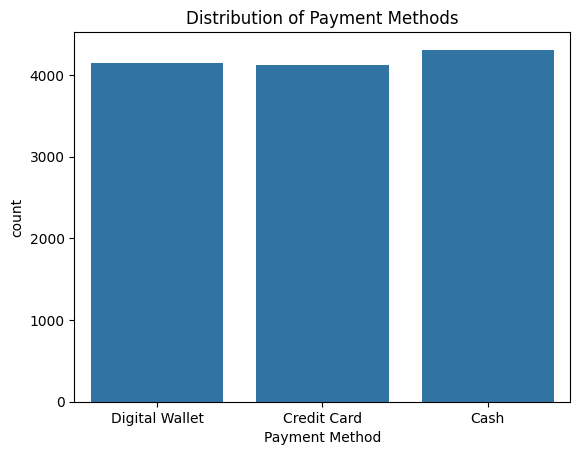

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Payment Method', data=df)
plt.title("Distribution of Payment Methods")
plt.show()

Each category is assigned a numeric label. This method is simple and efficient but may introduce false ordering relationships between categories.

# **Ordinal Encoding**

In [31]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
# Convert the 'Discount Applied' column to string type to ensure uniform input
df['Discount Applied'] = df['Discount Applied'].astype(str)
df['Discount_Ordinal'] = oe.fit_transform(df[['Discount Applied']])
print(df[['Discount Applied','Discount_Ordinal']].head())

  Discount Applied  Discount_Ordinal
0             True               1.0
1             True               1.0
2            False               0.0
3            False               0.0
4            False               0.0


Ordinal Encoding is used when categorical values have a natural order or ranking. In this method, categories are assigned numerical values based on their order or level. For example, in the Retail Store Sales dataset, the Discount Applied column may contain values such as True or False. These values can be encoded as 1 and 0 respectively. Ordinal encoding preserves the logical relationship between categories, making it useful for variables that represent levels or rankings. This technique is simple and efficient because it uses a single column to represent the encoded values. However, it should only be used when the categories have a meaningful order; otherwise, it may introduce incorrect assumptions about the data.

# **BINARY ENCODING**

In [33]:
!pip install category_encoders
import category_encoders as ce

binary_encoder = ce.BinaryEncoder(cols=['Category'])

df_binary = binary_encoder.fit_transform(df)

print(df_binary.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00
  Transaction ID Customer ID  Category_0  Category_1  Category_2  Category_3  \
0    TXN_6867343     CUST_09           0           0           0           1   
1    TXN_3731986     CUST_22           0           0           1           0   
2    TXN_9303719     CUST_02           0           0           1           1   
3    TXN_9458126     CUST_06           0           1           0           0   
4    TXN_4575373     CUST_05           0           1           0           1   

           Item  Price Per Unit  Quantity  Total Spent  ... Discount Applied  \
0   Item_10_PAT            18.5      10.0        185.0  ...             True   
1  Item_17_MILK            29.0       9.0        261.0  ...             True   
2   Item_12_BUT            21.5       2.0         43.0  ...            False   
3   Item_16_BEV            27.5       9.0        247.5  ...            False   
4   Item_6_FOOD            12.5       7.0

**Binary Encoding** is an advanced encoding technique that combines the advantages of label encoding and one-hot encoding. In this method, categorical values are first converted into numerical labels and then transformed into binary numbers. Each binary digit is stored in a separate column. For example, the Category column in the Retail Store Sales dataset may be converted into binary representations such as 001, 010, and 011. This approach significantly reduces the number of columns compared to one-hot encoding while still representing categorical information effectively. Binary encoding is particularly useful when a dataset contains many unique categories, as it reduces dimensionality and improves computational efficiency. However, the encoded binary values may be harder to interpret compared to other encoding methods.

# **FREQUENCY ENCODING**

In [34]:
freq = df['Location'].value_counts()
df['Location_Freq'] = df['Location'].map(freq)
print(df[['Location','Location_Freq']].head())

  Location  Location_Freq
0   Online           6354
1   Online           6354
2   Online           6354
3   Online           6354
4   Online           6354


Frequency encoding is a technique that replaces categorical values with the number of times they appear in the dataset. Instead of creating multiple columns, each category is replaced with its frequency count. For example, in the Retail Store Sales dataset, the Location column may contain cities such as Chennai, Mumbai, and Delhi. If Chennai appears 120 times, Mumbai appears 95 times, and Delhi appears 80 times in the dataset, these frequency values can replace the original category names. This method helps reduce the dimensionality of the dataset and can provide useful information about how common each category is. Frequency encoding is simple to implement and works well with large datasets, but it may cause different categories to share the same encoded value if their frequencies are equal.


# TARGET ENCODING

In [35]:
target_mean = df.groupby('Category')['Total Spent'].mean()
df['Category_Target'] = df['Category'].map(target_mean)
print(df[['Category','Category_Target']].head())

        Category  Category_Target
0     Patisserie       126.600310
1  Milk Products       119.518518
2       Butchers       138.681751
3      Beverages       131.622740
4           Food       129.290843


Target Encoding is a more advanced technique that replaces categorical values with the average value of a target variable associated with that category. This method is particularly useful when building predictive models. In the Retail Store Sales dataset, the Category column can be encoded using the average value of the Total Spent variable for each category. For example, if customers spend an average of 850 on Electronics, 420 on Clothing, and 310 on Groceries, these values can be used to replace the category names. Target encoding helps capture the relationship between categorical variables and the target variable, which can improve the performance of machine learning models. However, it must be applied carefully because it may lead to data leakage if the encoding is performed incorrectly during model training.

# **Final Summary**:

Feature engineering plays a critical role in preparing data for analysis and machine learning. In this stage, the dataset was cleaned and transformed to improve its usability. Numerical features were normalized and standardized to ensure consistent scales across variables. Categorical variables were encoded so that machine learning algorithms could interpret them correctly. Additionally, skewed distributions were corrected using logarithmic transformation to make the data more balanced. Visualizations were used throughout the process to understand the distribution of variables and verify the effectiveness of the transformations. These steps improve the quality of the dataset and help produce more accurate and reliable predictive models.